All libraries imported successfully!
DATASET OVERVIEW

Dataset Shape: (70000, 13)
Total Records: 70000
Total Features: 13

First 5 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Last 5 rows:
          id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
69995  99993  19240       2     168    76.0    120     80            1     1   
69996  99995  22601       1     158   126.0    140  

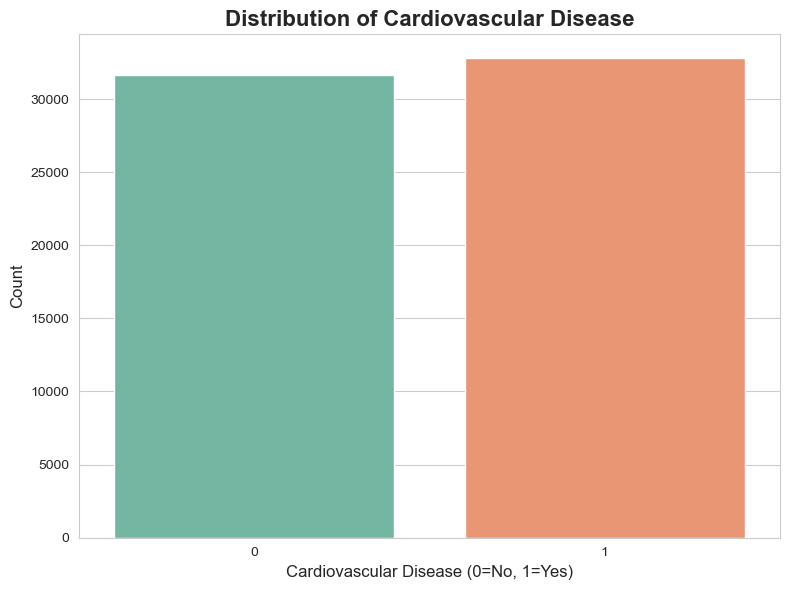

✓ Saved: 1_target_distribution.png


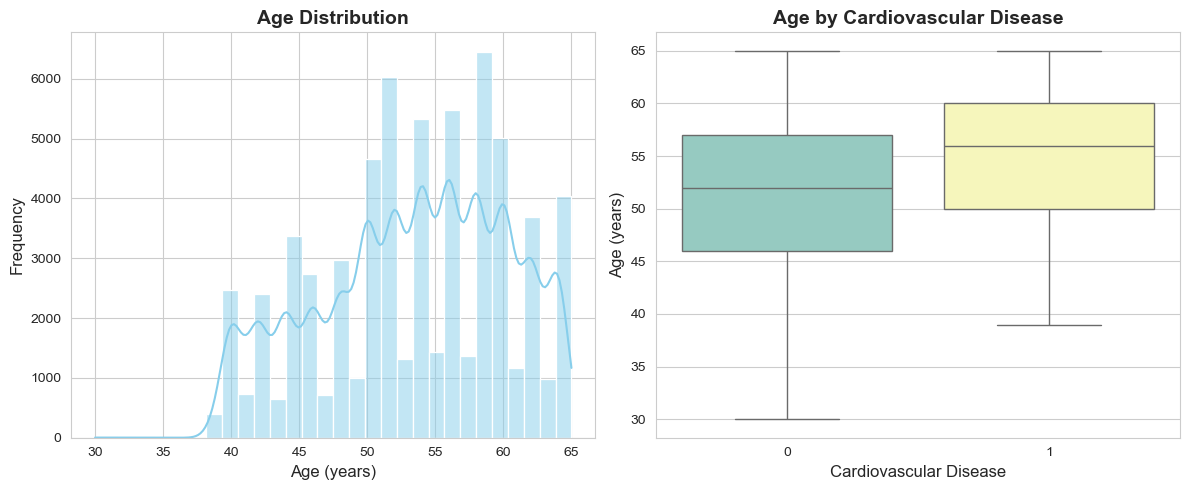

✓ Saved: 2_age_analysis.png


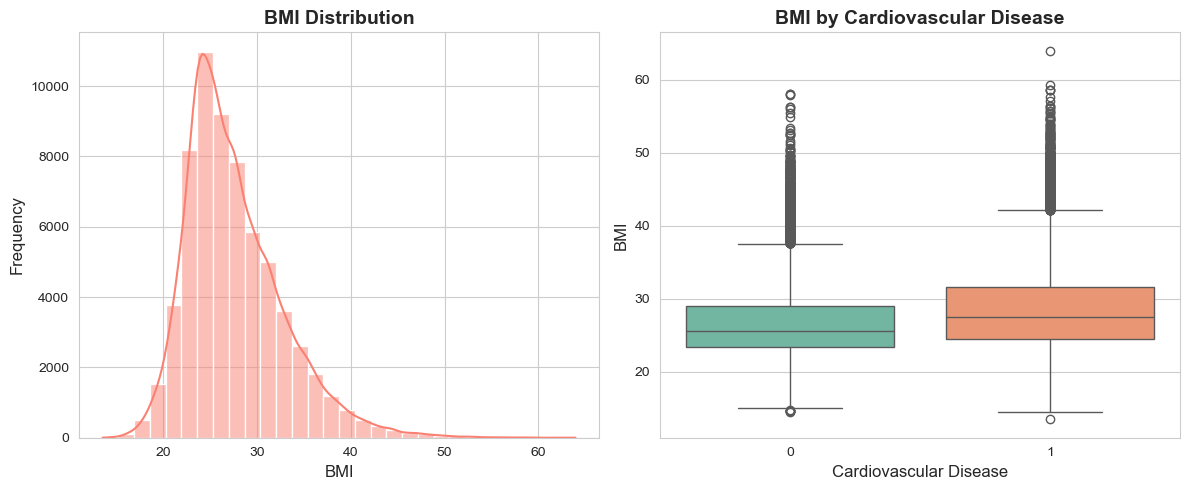

✓ Saved: 3_bmi_analysis.png


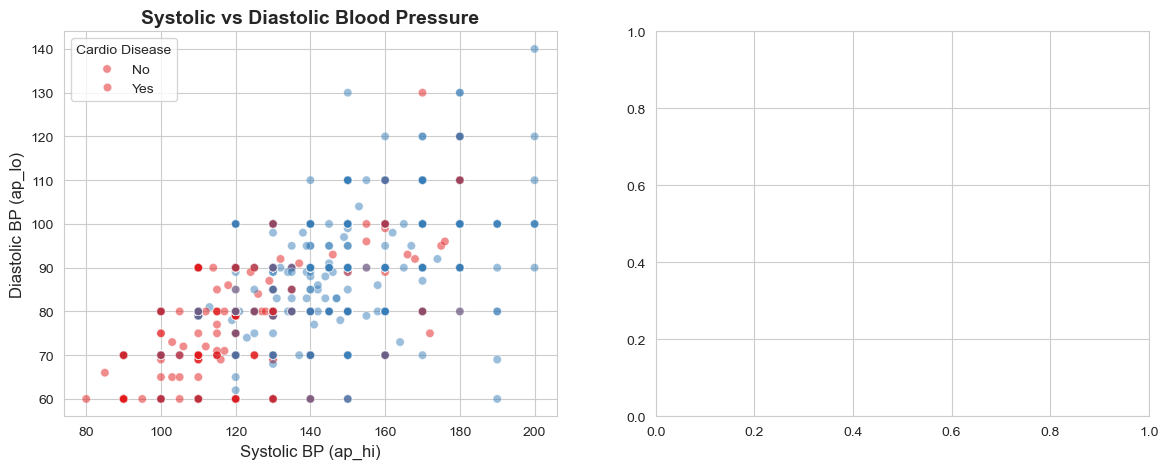

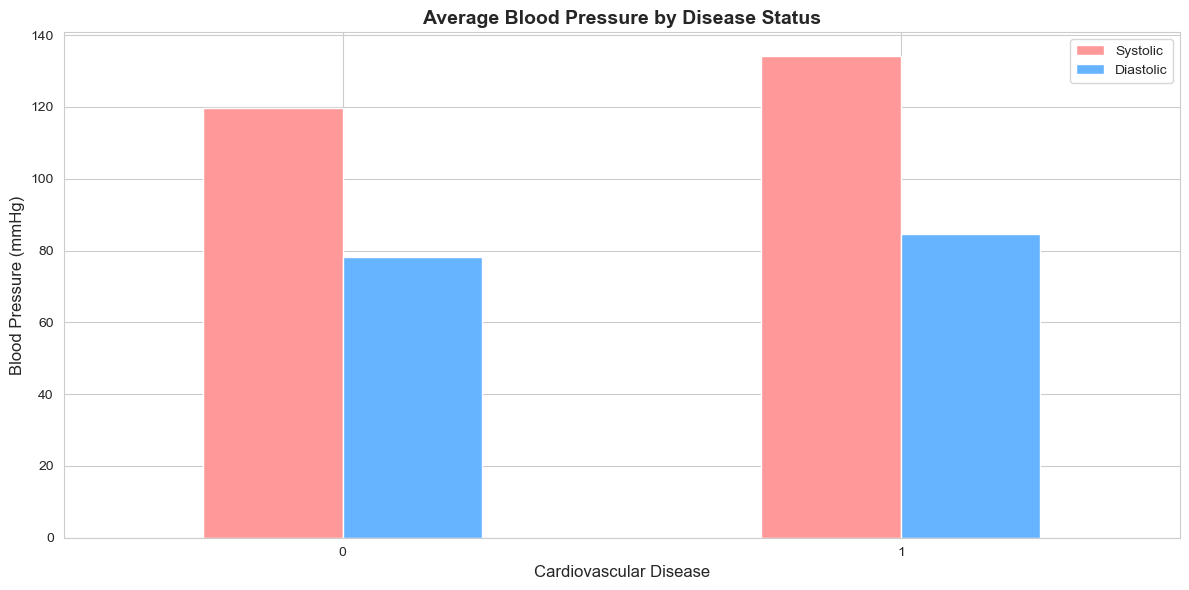

✓ Saved: 4_blood_pressure_analysis.png


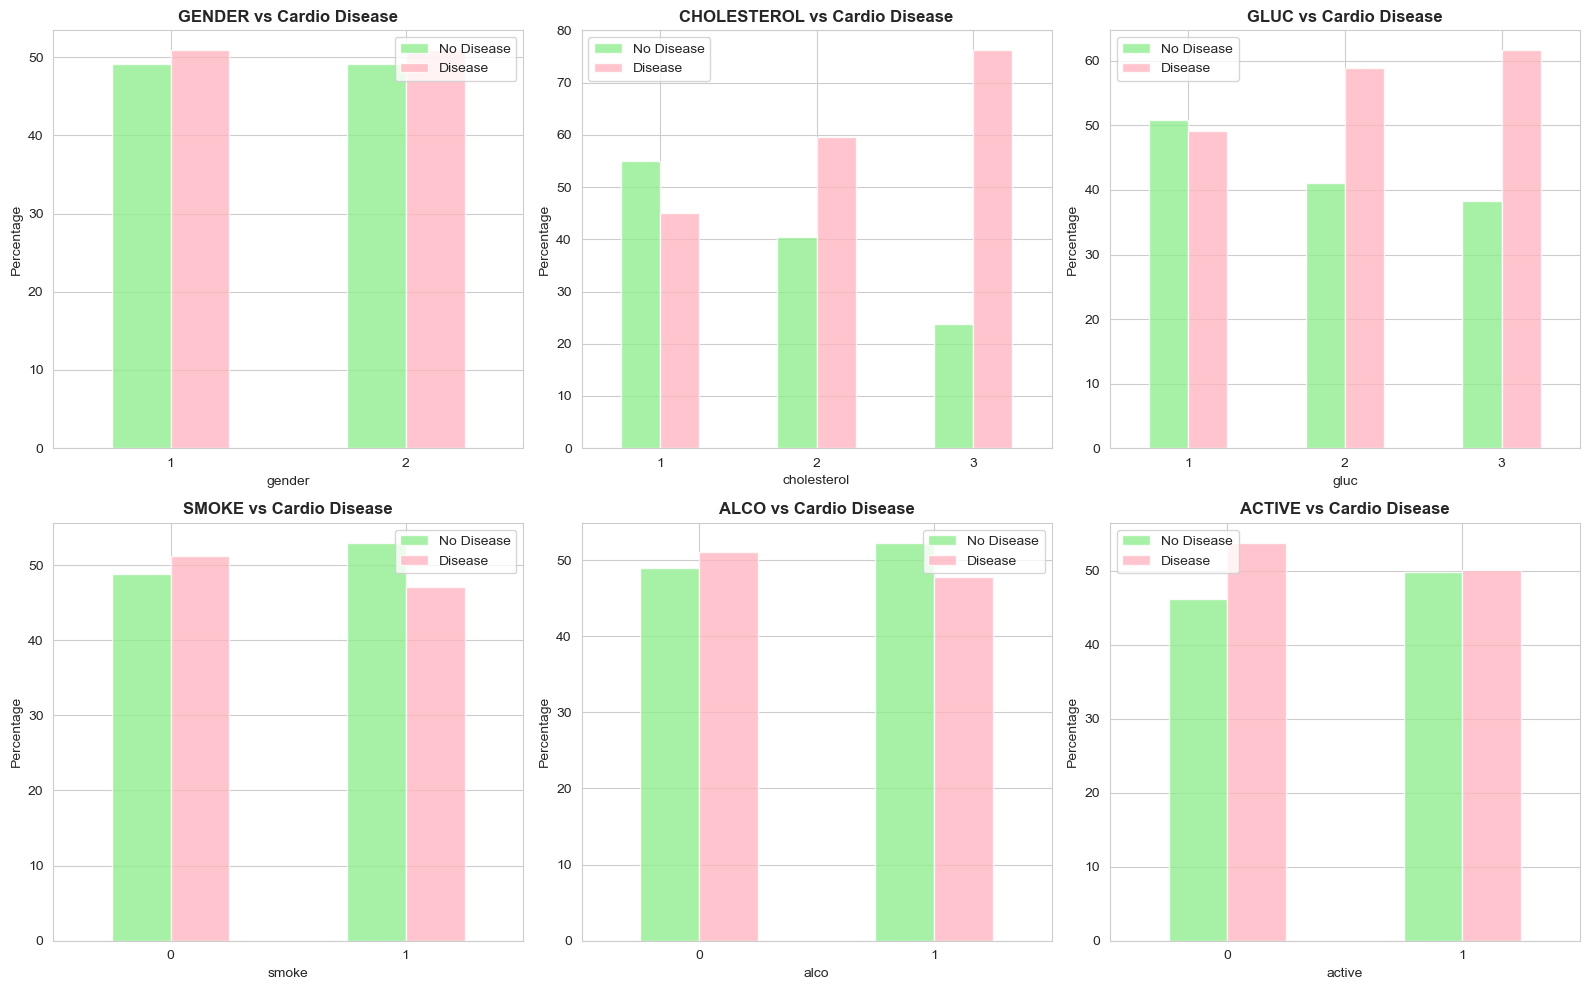

✓ Saved: 5_categorical_features.png


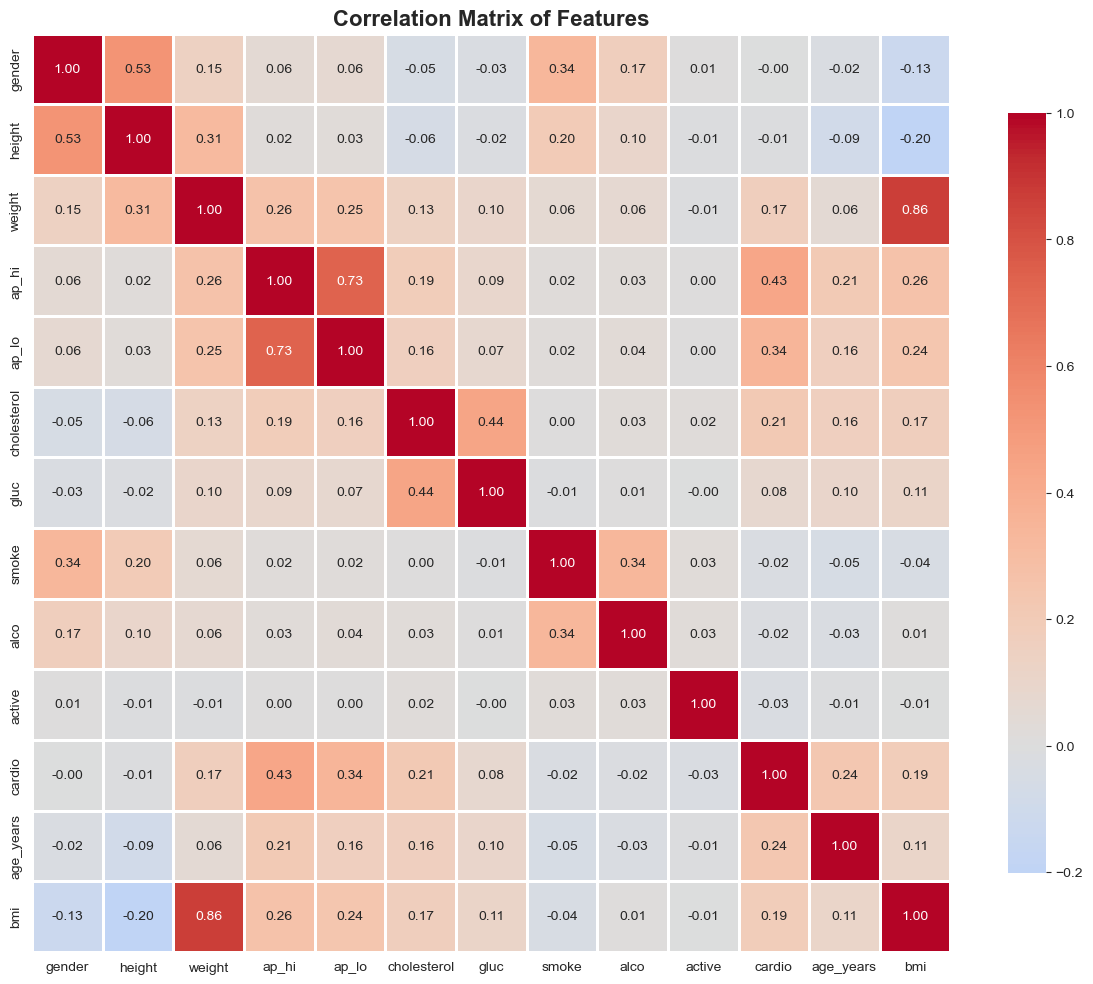

✓ Saved: 6_correlation_heatmap.png

FEATURE ENGINEERING
✓ Pulse pressure calculated
✓ Age groups created
✓ BMI categories created

PREPARING FEATURES FOR MODELING
Feature matrix shape: (64450, 13)
Target vector shape: (64450,)

Selected Features: ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure']

SPLITTING DATA
Training set size: 51560 (80.0%)
Test set size: 12890 (20.0%)

Training set class distribution:
cardio
1    26226
0    25334
Name: count, dtype: int64

Test set class distribution:
cardio
1    6557
0    6333
Name: count, dtype: int64

FEATURE SCALING
✓ Features scaled using StandardScaler
Scaled training data shape: (51560, 13)

MODEL TRAINING

Training Logistic Regression...
✓ Logistic Regression trained successfully
  Accuracy: 0.7269
  Precision: 0.7519
  Recall: 0.6912
  F1-Score: 0.7203
  ROC-AUC: 0.7886

Training Decision Tree...
✓ Decision Tree trained successfully
  Accuracy: 0.6093
  

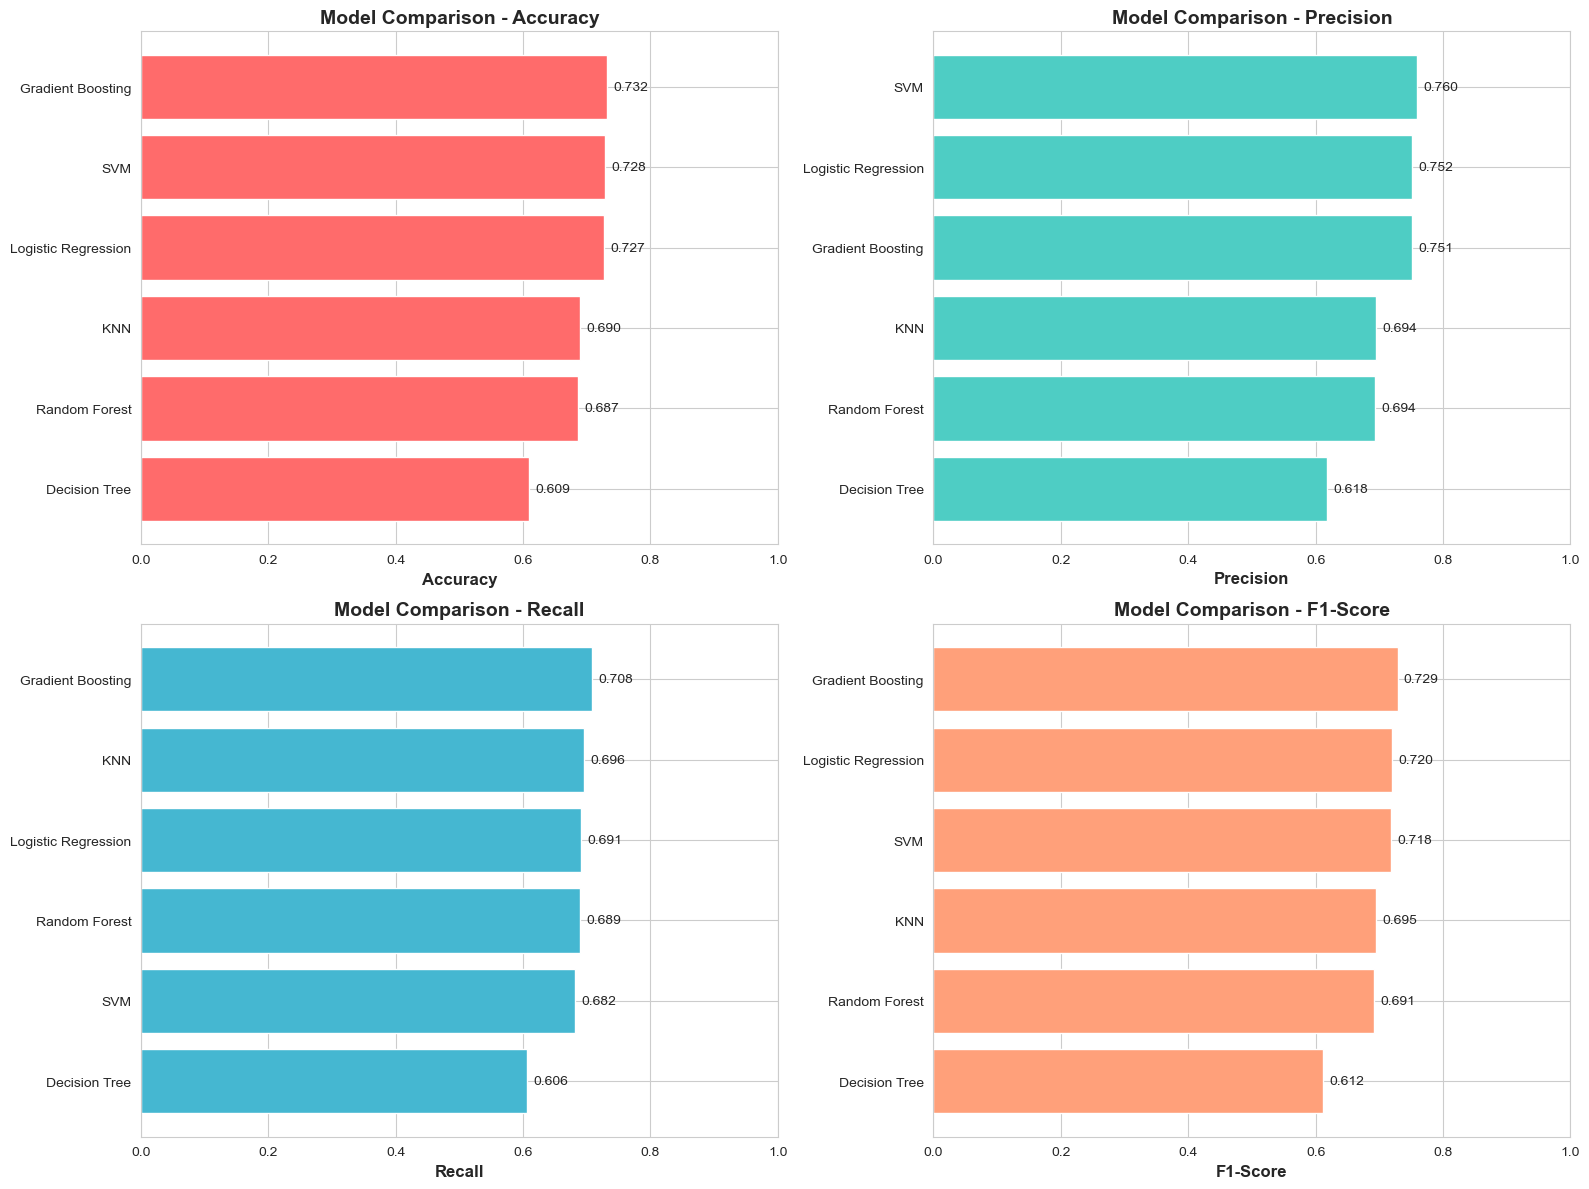


✓ Saved: 7_model_comparison.png


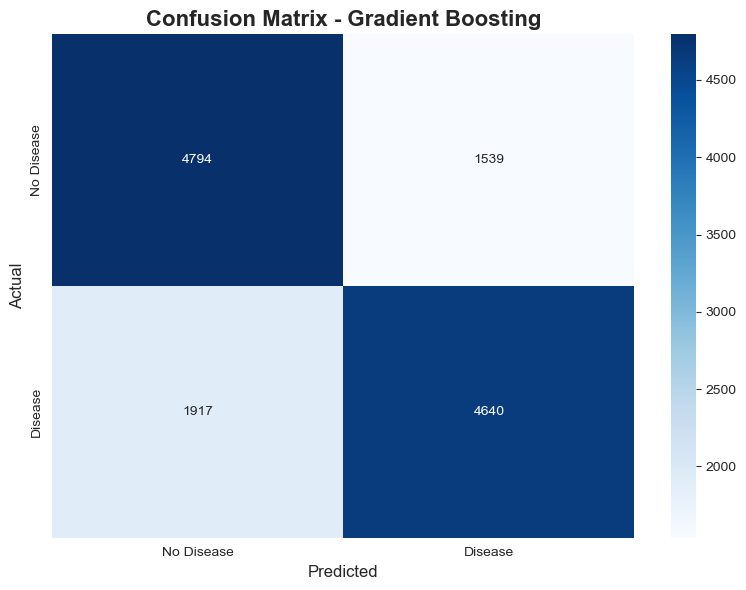

✓ Saved: 8_confusion_matrix.png


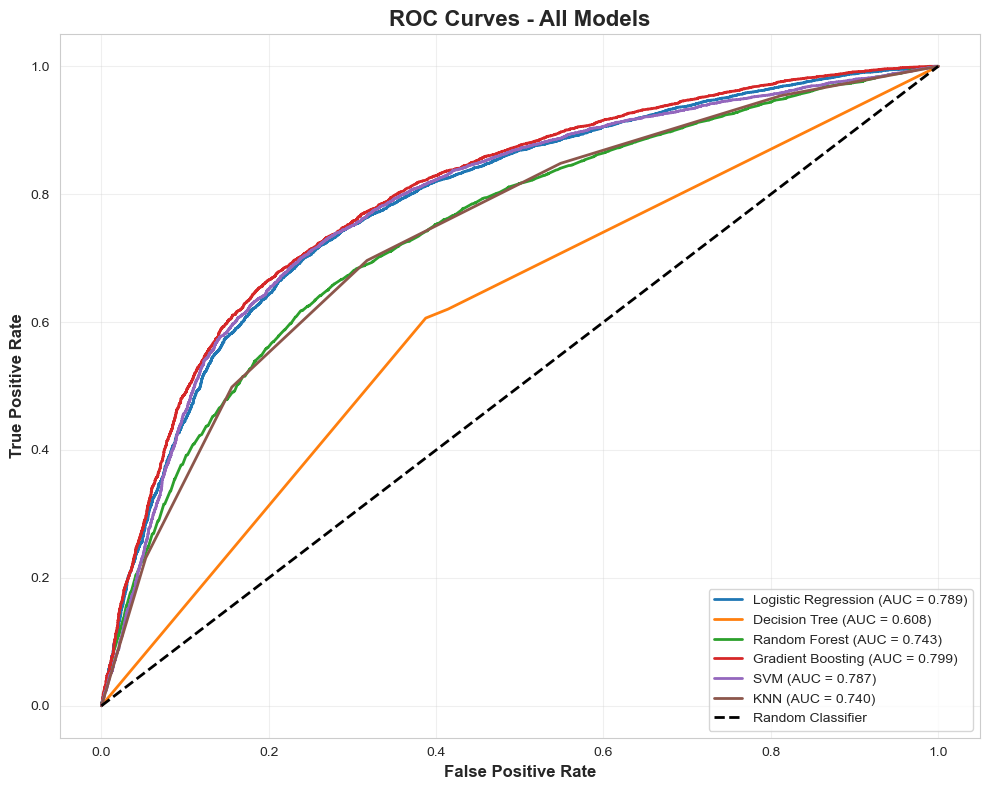

✓ Saved: 9_roc_curves.png

DETAILED CLASSIFICATION REPORT - Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.71      0.76      0.74      6333
     Disease       0.75      0.71      0.73      6557

    accuracy                           0.73     12890
   macro avg       0.73      0.73      0.73     12890
weighted avg       0.73      0.73      0.73     12890


FEATURE IMPORTANCE ANALYSIS
       Feature  Importance
         ap_hi    0.745216
     age_years    0.119592
   cholesterol    0.078349
           bmi    0.015739
         ap_lo    0.011916
        weight    0.007080
          gluc    0.005458
        active    0.004999
        height    0.003568
         smoke    0.002955
pulse_pressure    0.002830
          alco    0.001737
        gender    0.000561


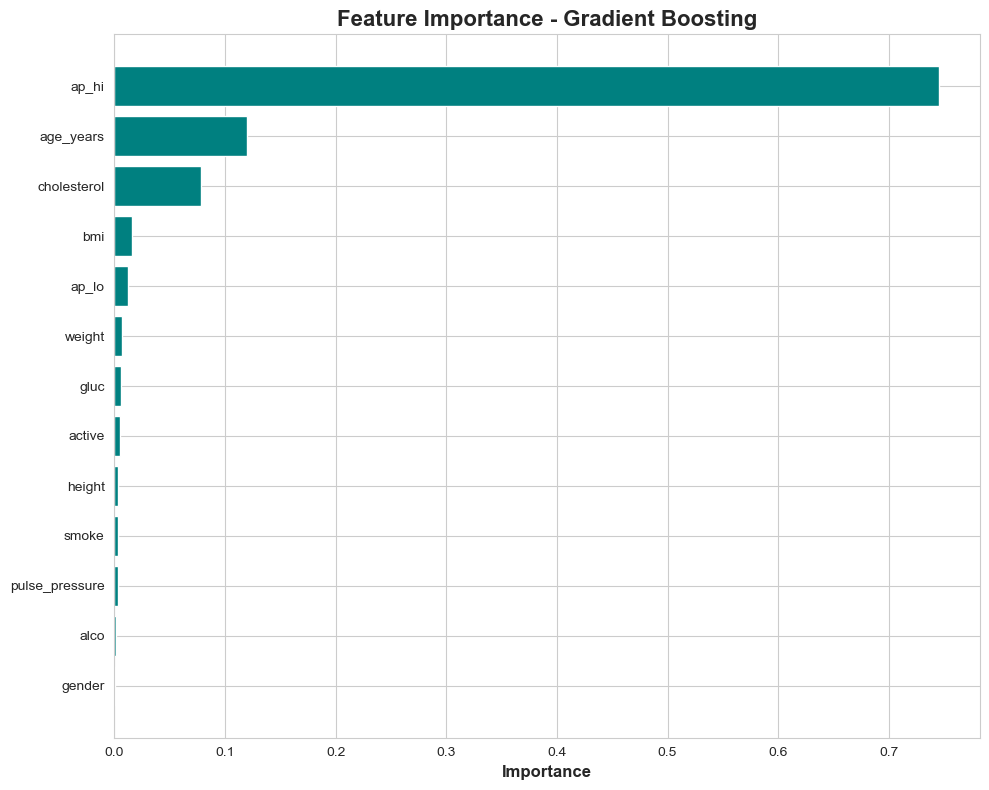


✓ Saved: 10_feature_importance.png

HYPERPARAMETER TUNING

ANALYSIS COMPLETE!

✓ Total patients analyzed: 64450
✓ Models trained: 6
✓ Best performing model: Gradient Boosting
✓ Best F1-Score: 0.7286
✓ Visualizations saved: 10 images

All analysis completed successfully!
Check your working directory for saved plots.


In [1]:
# Cardiovascular Disease Prediction - Machine Learning Analysis
# Dataset: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset

# ============================================================================
# SECTION 1: IMPORT LIBRARIES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

# ============================================================================
# SECTION 2: LOAD AND EXPLORE DATA
# ============================================================================

# Load the dataset
# Note: Replace with your actual file path after downloading from Kaggle
df = pd.read_csv('cardio_train.csv', sep=';')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Display last few rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset information
print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# Check for duplicates
print("\n" + "=" * 80)
print("DUPLICATE RECORDS")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# ============================================================================
# SECTION 3: DATA PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Create a copy for preprocessing
df_clean = df.copy()

# Convert age from days to years
df_clean['age_years'] = (df_clean['age'] / 365).round().astype(int)

# Calculate BMI (Body Mass Index)
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

# Remove ID column (not useful for prediction)
df_clean = df_clean.drop('id', axis=1)

# Remove original age column (we have age_years now)
df_clean = df_clean.drop('age', axis=1)

print("✓ Age converted to years")
print("✓ BMI calculated")
print("✓ ID column removed")

# Detect and handle outliers in blood pressure
print("\nHandling outliers in blood pressure...")
# Remove impossible blood pressure values
df_clean = df_clean[
    (df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 200) &
    (df_clean['ap_lo'] >= 60) & (df_clean['ap_lo'] <= 140) &
    (df_clean['ap_hi'] > df_clean['ap_lo'])
]
print(f"✓ Removed {df.shape[0] - df_clean.shape[0]} records with invalid blood pressure")

# Remove outliers in height and weight
print("\nHandling outliers in height and weight...")
df_clean = df_clean[
    (df_clean['height'] >= 140) & (df_clean['height'] <= 210) &
    (df_clean['weight'] >= 40) & (df_clean['weight'] <= 150)
]
print(f"✓ Total records after cleaning: {df_clean.shape[0]}")

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"✓ Records after removing duplicates: {df_clean.shape[0]}")

# ============================================================================
# SECTION 4: STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS")
print("=" * 80)

# Basic statistics
print("\nDescriptive Statistics:")
print(df_clean.describe())

# Calculate skewness and kurtosis for numerical features
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

print("\n" + "=" * 80)
print("SKEWNESS AND KURTOSIS")
print("=" * 80)
print(f"{'Feature':<15} {'Mean':<10} {'Std':<10} {'Skewness':<12} {'Kurtosis':<12}")
print("-" * 80)

for feature in numerical_features:
    mean_val = df_clean[feature].mean()
    std_val = df_clean[feature].std()
    skew_val = df_clean[feature].skew()
    kurt_val = df_clean[feature].kurtosis()
    print(f"{feature:<15} {mean_val:<10.2f} {std_val:<10.2f} {skew_val:<12.3f} {kurt_val:<12.3f}")

# Target variable distribution
print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)
target_counts = df_clean['cardio'].value_counts()
print(target_counts)
print(f"\nClass Distribution:")
print(f"No Disease (0): {target_counts[0]} ({target_counts[0]/len(df_clean)*100:.2f}%)")
print(f"Disease (1): {target_counts[1]} ({target_counts[1]/len(df_clean)*100:.2f}%)")

# ============================================================================
# SECTION 5: DATA VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

# 1. Target Variable Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='cardio', palette='Set2')
plt.title('Distribution of Cardiovascular Disease', fontsize=16, fontweight='bold')
plt.xlabel('Cardiovascular Disease (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('1_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 1_target_distribution.png")

# 2. Age Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='age_years', bins=30, kde=True, color='skyblue')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, y='age_years', x='cardio', palette='Set3')
plt.title('Age by Cardiovascular Disease', fontsize=14, fontweight='bold')
plt.xlabel('Cardiovascular Disease', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.savefig('2_age_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 2_age_analysis.png")

# 3. BMI Analysis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='bmi', bins=30, kde=True, color='salmon')
plt.title('BMI Distribution', fontsize=14, fontweight='bold')
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, y='bmi', x='cardio', palette='Set2')
plt.title('BMI by Cardiovascular Disease', fontsize=14, fontweight='bold')
plt.xlabel('Cardiovascular Disease', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.tight_layout()
plt.savefig('3_bmi_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 3_bmi_analysis.png")

# 4. Blood Pressure Analysis
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean.sample(5000), x='ap_hi', y='ap_lo', 
                hue='cardio', alpha=0.5, palette='Set1')
plt.title('Systolic vs Diastolic Blood Pressure', fontsize=14, fontweight='bold')
plt.xlabel('Systolic BP (ap_hi)', fontsize=12)
plt.ylabel('Diastolic BP (ap_lo)', fontsize=12)
plt.legend(title='Cardio Disease', labels=['No', 'Yes'])

plt.subplot(1, 2, 2)
df_clean[['ap_hi', 'ap_lo', 'cardio']].groupby('cardio').mean().plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('Average Blood Pressure by Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Cardiovascular Disease', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Systolic', 'Diastolic'])
plt.tight_layout()
plt.savefig('4_blood_pressure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 4_blood_pressure_analysis.png")

# 5. Categorical Features Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for idx, feature in enumerate(categorical_features):
    row = idx // 3
    col = idx % 3
    
    cross_tab = pd.crosstab(df_clean[feature], df_clean['cardio'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=axes[row, col], color=['#90EE90', '#FFB6C1'], alpha=0.8)
    axes[row, col].set_title(f'{feature.upper()} vs Cardio Disease', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('Percentage', fontsize=10)
    axes[row, col].legend(['No Disease', 'Disease'], loc='best')
    axes[row, col].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('5_categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 5_categorical_features.png")

# 6. Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 6_correlation_heatmap.png")

# ============================================================================
# SECTION 6: FEATURE ENGINEERING & SELECTION
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Create pulse pressure feature
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']

# Create age groups
df_clean['age_group'] = pd.cut(df_clean['age_years'], 
                                bins=[0, 40, 50, 60, 100], 
                                labels=['<40', '40-50', '50-60', '60+'])

# Create BMI categories
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], 
                                   bins=[0, 18.5, 25, 30, 100],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print("✓ Pulse pressure calculated")
print("✓ Age groups created")
print("✓ BMI categories created")

# Prepare features for modeling
print("\n" + "=" * 80)
print("PREPARING FEATURES FOR MODELING")
print("=" * 80)

# Select features for modeling
feature_columns = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                   'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure']

X = df_clean[feature_columns]
y = df_clean['cardio']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nSelected Features: {list(X.columns)}")

# ============================================================================
# SECTION 7: TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("SPLITTING DATA")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

# ============================================================================
# SECTION 8: FEATURE SCALING
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE SCALING")
print("=" * 80)

# Use StandardScaler for normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"Scaled training data shape: {X_train_scaled.shape}")

# ============================================================================
# SECTION 9: MODEL TRAINING
# ============================================================================

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

# Dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"✓ {name} trained successfully")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC: {roc_auc:.4f}")

# ============================================================================
# SECTION 10: MODEL EVALUATION & COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] if results[m]['roc_auc'] else 0 for m in results.keys()]
})

print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {results[best_model_name]['f1_score']:.4f}")

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    comparison_df_sorted = comparison_df.sort_values(by=metric, ascending=True)
    axes[row, col].barh(comparison_df_sorted['Model'], comparison_df_sorted[metric], color=colors[idx])
    axes[row, col].set_xlabel(metric, fontsize=12, fontweight='bold')
    axes[row, col].set_title(f'Model Comparison - {metric}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlim([0, 1])
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df_sorted[metric]):
        axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('7_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 7_model_comparison.png")

# Confusion Matrix for best model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('8_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 8_confusion_matrix.png")

# ROC Curves
plt.figure(figsize=(10, 8))
for name in results.keys():
    if results[name]['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('9_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 9_roc_curves.png")

# Classification Report for best model
print("\n" + "=" * 80)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("=" * 80)
print(classification_report(y_test, results[best_model_name]['predictions'],
                          target_names=['No Disease', 'Disease']))

# ============================================================================
# SECTION 11: FEATURE IMPORTANCE (for tree-based models)
# ============================================================================

if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    print("\n" + "=" * 80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': results[best_model_name]['model'].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('10_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: 10_feature_importance.png")

# ============================================================================
# SECTION 12: HYPERPARAMETER TUNING (Optional - for best model)
# ============================================================================

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING")
print("=" * 80)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    print(f"Tuning {best_model_name} with Grid Search...")
    print("This may take a few minutes...")
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"\n✓ Best parameters: {grid_search.best_params_}")
    print(f"✓ Best cross-validation F1-Score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    y_pred_tuned = grid_search.predict(X_test_scaled)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    
    print(f"\n📊 Tuned Model Performance:")
    print(f"   Accuracy: {accuracy_tuned:.4f}")
    print(f"   F1-Score: {f1_tuned:.4f}")
    print(f"   Improvement: {(f1_tuned - results[best_model_name]['f1_score']):.4f}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\n✓ Total patients analyzed: {len(df_clean)}")
print(f"✓ Models trained: {len(models)}")
print(f"✓ Best performing model: {best_model_name}")
print(f"✓ Best F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f"✓ Visualizations saved: 10 images")
print("\nAll analysis completed successfully!")
print("Check your working directory for saved plots.")
print("=" * 80)